In [1]:
import pandas as pd 
import numpy as np
import matplotlib as mp
import seaborn as sb


In [2]:
matches_df = pd.read_csv("Datasets/matches.csv")
delivereies_df = pd.read_csv("Datasets/deliveries.csv")

In [3]:
delivereies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [4]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [5]:
teams = {
    'Royal Challengers Bengaluru',
    'Punjab Kings',
    'Mumbai Indians',
    'Kolkata Knight Riders',
    'Chennai Super Kings',
    'Lucknow Super Giants',
    'Rajasthan Royals',
    'Gujarat Titans',
    'Sunrisers Hyderabad',
    'Delhi Capitals'
}

In [6]:

matches_df['city'].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', nan, 'Rajkot', 'Kanpur', 'Bengaluru', 'Dubai',
       'Sharjah', 'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali'],
      dtype=object)

In [7]:
new_matches_df = matches_df[['id','city','target_runs']]

In [8]:
delivereies_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [9]:
new_delivereies_df = delivereies_df[['match_id','inning','batting_team','bowling_team','over','ball', 'batsman_runs','total_runs','is_wicket','extra_runs','extras_type']]

In [10]:
new_delivereies_df['batting_team'] =new_delivereies_df['batting_team'].str.replace('Delhi Daredevils','Delhi Capitals')
new_delivereies_df['bowling_team'] = new_delivereies_df['bowling_team'].str.replace('Delhi Daredevils','Delhi Capitals')

new_delivereies_df['batting_team'] = new_delivereies_df['batting_team'].str.replace('Deccan Chargers','Sunrisers Hyderabad')
new_delivereies_df['bowling_team'] = new_delivereies_df['bowling_team'].str.replace('Deccan Chargers','Sunrisers Hyderabad')


C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\2628510353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_delivereies_df['batting_team'] =new_delivereies_df['batting_team'].str.replace('Delhi Daredevils','Delhi Capitals')
C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\2628510353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_delivereies_df['bowling_team'] = new_delivereies_df['bowling_team'].str.replace('Delhi Daredevils','Delhi Capitals')
C:\Users\DELL\AppData\Local\Temp\ipykernel_2024

In [11]:
new_delivereies_df = new_delivereies_df[new_delivereies_df['batting_team'].isin(teams)]
new_delivereies_df = new_delivereies_df[new_delivereies_df['bowling_team'].isin(teams)]

In [12]:
new_delivereies_df['batting_team'].unique()

array(['Rajasthan Royals', 'Delhi Capitals', 'Sunrisers Hyderabad',
       'Kolkata Knight Riders', 'Chennai Super Kings', 'Mumbai Indians',
       'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [13]:
new_matches_df.rename(columns={'id':'match_id'}, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\2620904377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_matches_df.rename(columns={'id':'match_id'}, inplace=True)


In [14]:
df = new_matches_df.merge(new_delivereies_df,on='match_id')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145513 entries, 0 to 145512
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   match_id      145513 non-null  int64  
 1   city          138973 non-null  object 
 2   target_runs   145395 non-null  float64
 3   inning        145513 non-null  int64  
 4   batting_team  145513 non-null  object 
 5   bowling_team  145513 non-null  object 
 6   over          145513 non-null  int64  
 7   ball          145513 non-null  int64  
 8   batsman_runs  145513 non-null  int64  
 9   total_runs    145513 non-null  int64  
 10  is_wicket     145513 non-null  int64  
 11  extra_runs    145513 non-null  int64  
 12  extras_type   7948 non-null    object 
dtypes: float64(1), int64(8), object(4)
memory usage: 14.4+ MB


In [16]:
df = df[df['inning'] == 2]

In [17]:
df.shape

(70131, 13)

In [18]:
# created current score coloum 
df['current_score']  = df.groupby('match_id')['total_runs'].cumsum().shift(1).fillna(0)

In [19]:
# how many runs are left for batting team to win the match
df['runs_left'] = df['target_runs'] - df['current_score']

In [20]:
# # how many balls the left that the colums work
legal_ball = ~df['extras_type'].isin(['wides','noballs'])

df['balls_left'] = 120 - legal_ball.groupby(df['match_id']).cumsum()

In [21]:
# # run/overs
df['crr'] = (df['current_score'] * 6 )/(120 - df['balls_left']).replace(0,1)

In [22]:
# how many runs are scored in last 3 balls
df['last_3_balls_runs'] = (
    df.groupby(['match_id','inning'])['total_runs']
    .rolling(3, min_periods=1)
    .sum()
    .reset_index(level=[0,1], drop=True)
   
)
df['last_3_balls_runs'] = df.groupby('match_id')['last_3_balls_runs'].shift(1)
df['last_3_balls_runs'] = df['last_3_balls_runs'].fillna(0)

In [23]:
# how many runs are scored in last 5 balls
df['last_5_balls_runs'] = (
    df.groupby(['match_id','inning'])['total_runs']
    .rolling(5, min_periods=1)
    .sum()
    .reset_index(level=[0,1], drop=True)
)
df['last_5_balls_runs'] = df.groupby('match_id')['last_5_balls_runs'].shift(1)
df['last_5_balls_runs'] = df['last_5_balls_runs'].fillna(0)

df['strike_momentum'] = df['last_5_balls_runs'] / 5



In [24]:
# how many runs are scored in last 18 balls
df['last_18_balls_runs'] = (
    df.groupby(['match_id','inning'])['total_runs']
    .rolling(18, min_periods=1)
    .sum()
    .reset_index(level=[0,1], drop=True)
)

df['last_18_balls_runs'] = df.groupby('match_id')['last_18_balls_runs'].shift(1)
df['last_18_balls_runs'] = df['last_18_balls_runs'].fillna(0)

In [25]:
# run rate required
df['rrr'] = df['runs_left'] / (df['balls_left'] / 6).replace(0,1)
df['rr_gap'] = df['rrr'] - df['crr']

In [26]:
# that wickiet alllowed
wickets = df.groupby('match_id')['is_wicket'].cumsum().shift(1).fillna(0)
df['rrr_x_wickets'] = df['rrr'] * wickets
df['wickets'] = 10 - wickets


In [27]:
# RUNS PER WICKET — chasing ma risk indicator
df['runs_per_wicket'] = (
    df['current_score'] / (11 - df['wickets']).replace(0, 1)
)

In [28]:
df.head(20)

,match_id,city,target_runs,inning,batting_team,bowling_team,over,ball,batsman_runs,total_runs,...,crr,last_3_balls_runs,last_5_balls_runs,strike_momentum,last_18_balls_runs,rrr,rr_gap,rrr_x_wickets,wickets,runs_per_wicket
122,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,0,1,0,0,...,0.000000,0.0,0.0,0.0,0.0,6.554622,6.554622,0.000000,10.0,0.0
123,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,0,2,0,0,...,0.000000,0.0,0.0,0.0,0.0,6.610169,6.610169,0.000000,10.0,0.0
124,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,0,3,0,0,...,0.000000,0.0,0.0,0.0,0.0,6.666667,6.666667,0.000000,10.0,0.0
125,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,0,4,0,0,...,0.000000,0.0,0.0,0.0,0.0,6.724138,6.724138,0.000000,10.0,0.0
126,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,0,5,4,4,...,0.000000,0.0,0.0,0.0,0.0,6.782609,6.782609,0.000000,10.0,0.0
127,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,0,6,4,4,...,4.000000,4.0,4.0,0.8,4.0,6.631579,2.631579,0.000000,10.0,4.0
128,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,1,1,4,4,...,6.857143,8.0,8.0,1.6,8.0,6.477876,-0.379267,0.000000,10.0,8.0
129,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,1,2,4,4,...,9.000000,12.0,12.0,2.4,12.0,6.321429,-2.678571,0.000000,10.0,12.0
130,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,1,3,4,4,...,10.666667,12.0,16.0,3.2,16.0,6.162162,-4.504505,0.000000,10.0,16.0
131,335984,Delhi,130.0,2,Delhi Capitals,Rajasthan Royals,1,4,0,0,...,12.000000,12.0,20.0,4.0,20.0,6.000000,-6.000000,0.000000,10.0,20.0


In [29]:
# # match phase
# df['match_phase'] = df['over'].apply(lambda x: 'is_powerplay' if x <= 6 else ('is_middle' if 6 < x <= 15 else 'is_death'))

df['is_powerplay'] = df['over'].apply(lambda x: 1 if x <= 6 else 0)
df['is_middle'] = df['over'].apply(lambda x: 1 if 6 < x <= 15 else 0)
df['is_death'] = df['over'].apply(lambda x: 1 if x > 15 else 0)

In [30]:
# Step 1: outcome banavo 
df['outcome'] = df.apply(
    lambda row: 'W' if row['is_wicket'] == 1 else str(row['batsman_runs']),
    axis=1
)

# Step 2: only required values 
df = df[df['outcome'].isin(['0','1','2','3','4','6','W'])]

# Step 3: mapping (7 → 4 class)
mapping = {
    '0': 0,
    '1': 1, '2': 1, '3': 1,
    '4': 2, '6': 2,
    'W': 3
}
# output final column
df['new_outcome'] = df['outcome'].map(mapping)

# Step 4: check
print(df['outcome'].value_counts())
print(df['new_outcome'].value_counts())

# 0 Run -> class 0
# 1,2,3 Runs -> class 1
# 4,6 Runs -> class 2
# Wicket -> class 3

outcome
1    25617
0    24871
4     8109
2     4275
W     3524
6     3522
3      194
Name: count, dtype: int64
new_outcome
1    30086
0    24871
2    11631
3     3524
Name: count, dtype: int64


In [31]:
# how many runs are scored in current partnership
df['wicket_group'] = df.groupby('match_id')['is_wicket'].cumsum()
df['partnership_runs'] = (
    df.groupby(['match_id','wicket_group'])['total_runs']
    .cumsum()
)

# that current ball runs are not included in partnership runs
df['partnership_runs'] = df.groupby('match_id')['partnership_runs'].shift(1)
df['partnership_runs'] = df['partnership_runs'].fillna(0)

In [32]:
# boundary flag
df['is_boundary'] = df['outcome'].isin(['4', '6']).astype(int)

# rolling count
df['last_3_boundaries'] = (
    df.groupby('match_id')['is_boundary']
    .rolling(3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

# shift
df['last_3_boundaries'] = df.groupby('match_id')['last_3_boundaries'].shift(1)
df['last_3_boundaries'] = df['last_3_boundaries'].fillna(0)

In [33]:
df['last_6_balls_wickets'] = (
    df.groupby('match_id')['is_wicket']
    .rolling(6, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)
df['last_6_balls_wickets'] = df.groupby('match_id')['last_6_balls_wickets'].shift(1)
df['last_6_balls_wickets'] = df['last_6_balls_wickets'].fillna(0)

In [34]:
def calculate_dot_streak(outcomes):
    streak = 0
    result = []
   
    
    for val in outcomes:
        if val == '0':
           streak += 1

        else:
            streak = 0
        result.append(streak)
    
    return result

df['dot_streak'] = df.groupby('match_id')['outcome'].transform(calculate_dot_streak)
df['dot_streak'] = df.groupby('match_id')['dot_streak'].shift(1)
df['dot_streak'] = df['dot_streak'].fillna(0)

In [35]:
# 1. Identify a dot ball (1 if 0 runs, else 0)
df['is_dot'] = (df['total_runs'] == 0).astype(int)
# 2. Count dot balls in the last 6 balls (1 over) and 12 balls (2 overs)
df['dots_last_6'] = df.groupby(['match_id'])['is_dot'].rolling(6, min_periods=1).sum().reset_index(level=0, drop=True)
df['dots_last_6'] = df.groupby('match_id')['dots_last_6'].shift(1)
df['dots_last_6'] = df['dots_last_6'].fillna(0)


# Pressure is more dangerous when the Required Run Rate is already high
df['weighted_dot_pressure'] = df['dots_last_6'] * df['rrr']

In [36]:
df['previous_ball_runs'] = df.groupby('match_id')['batsman_runs'].shift(1)
df['previous_ball_runs'] = df['previous_ball_runs'].fillna(0)

In [37]:
df['is_new_batsman'] = df['is_wicket'].shift(1).fillna(0).astype(int)

In [38]:
df['legal_ball'] = ~df['extras_type'].isin(['wides', 'noballs'])

# 2. Calculate cumulative sum of legal balls PER OVER
# We group by match, inning, and over to ensure the count resets
df['balls_bowled_in_over'] = df.groupby(['match_id', 'inning', 'over'])['legal_ball'].cumsum()

# 3. Calculate balls remaining
df['balls_Remaining_in_over'] = 6 - df['balls_bowled_in_over']

In [39]:
# 2. Define the Finisher Alert criteria
# Logic: Death overs + At least 6 wickets in hand + RRR is under 8
from sqlalchemy import true


df['finisher_alert'] = (
    (df['is_death']) & 
    (df['wickets'] >= 6) & 
    (df['rrr'] <= 8.0)
).astype(int)

# 3. Add a "Momentum Finisher" (For aggressive finishes)
# Alert if RRR is high but the team just scored 25+ runs in the last 12 balls
df['momentum_finisher'] = (
    (df['is_death']) & 
    (df['last_18_balls_runs'] >= 30) & 
    (df['wickets'] >= 4)
).astype(int)      

In [40]:
df['is_free_hit'] = (
    (df['extras_type'] == 'noballs')
    .groupby([df['match_id'], df['inning']])
    .shift(1)
    .fillna(False)
    .astype(int)
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\172793244.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70112 entries, 122 to 145512
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   match_id                 70112 non-null  int64  
 1   city                     66920 non-null  object 
 2   target_runs              70112 non-null  float64
 3   inning                   70112 non-null  int64  
 4   batting_team             70112 non-null  object 
 5   bowling_team             70112 non-null  object 
 6   over                     70112 non-null  int64  
 7   ball                     70112 non-null  int64  
 8   batsman_runs             70112 non-null  int64  
 9   total_runs               70112 non-null  int64  
 10  is_wicket                70112 non-null  int64  
 11  extra_runs               70112 non-null  int64  
 12  extras_type              3765 non-null   object 
 13  current_score            70112 non-null  float64
 14  runs_left               

In [42]:
df['wickets']

122       10.0
123       10.0
124       10.0
125       10.0
126       10.0
          ... 
145508     8.0
145509     8.0
145510     8.0
145511     8.0
145512     8.0
Name: wickets, Length: 70112, dtype: float64

In [43]:
final_data = df[['batting_team','bowling_team','city','target_runs','current_score','rrr','last_6_balls_wickets','dots_last_6','wickets','is_powerplay','is_death', 'last_5_balls_runs', 'last_18_balls_runs','partnership_runs','momentum_finisher','new_outcome']]


In [44]:
corr = final_data.corr(numeric_only=True)
print(corr.round(2) * 100)

                      target_runs  current_score    rrr  last_6_balls_wickets  \
target_runs                 100.0           23.0   27.0                   7.0   
current_score                23.0          100.0   23.0                  12.0   
rrr                          27.0           23.0  100.0                  11.0   
last_6_balls_wickets          7.0           12.0   11.0                 100.0   
dots_last_6                 -12.0          -30.0    0.0                  33.0   
wickets                     -17.0          -64.0  -37.0                 -34.0   
is_powerplay                 -5.0          -73.0  -15.0                  -9.0   
is_death                      7.0           60.0   33.0                  15.0   
last_5_balls_runs            15.0           21.0    2.0                 -21.0   
last_18_balls_runs           23.0           48.0    5.0                  -3.0   
partnership_runs              0.0           20.0   -9.0                 -43.0   
momentum_finisher           

In [45]:
# final_data = df[['batting_team','bowling_team','city','over','crr','rrr','wickets','runs_per_wicket','is_powerplay','is_death','rrr_x_wickets','last_18_balls_runs','partnership_runs','last_6_balls_wickets','previous_ball_runs','is_new_batsman','momentum_finisher','new_outcome']]

<Axes: xlabel='new_outcome', ylabel='count'>

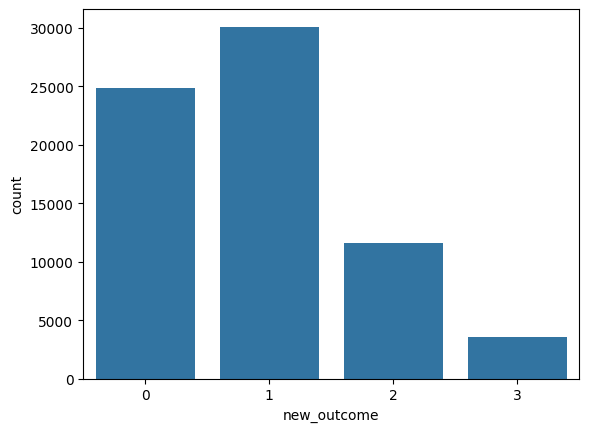

In [46]:
sb.countplot(x='new_outcome', data=final_data)

In [47]:
final_data.dropna(inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\325702340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data.dropna(inplace=True)


In [48]:
# final_data.info()

In [49]:
# final_data['runs_left'] = final_data['runs_left'].astype(int)
# final_data['last_5_balls_runs'] = final_data['last_5_balls_runs'].astype(int)
final_data['batting_team'] = final_data['batting_team'].astype('category')
final_data['bowling_team'] = final_data['bowling_team'].astype('category')
final_data['city'] = final_data['city'].astype('category')
# final_data['last_3_boundaries'] = final_data['last_3_boundaries'].astype(int)
final_data['partnership_runs'] = final_data['partnership_runs'].astype(int)
# final_data['last_6_balls_wickets'] = final_data['last_6_balls_wickets'].astype(int)
# final_data['dot_streak'] = final_data['dot_streak'].astype(int)     
# final_data['last_3_balls_runs'] = final_data['last_3_balls_runs'].astype(int)
final_data['last_18_balls_runs'] = final_data['last_18_balls_runs'].astype(int)

C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\1199573862.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['batting_team'] = final_data['batting_team'].astype('category')
C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\1199573862.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['bowling_team'] = final_data['bowling_team'].astype('category')
C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\1199573862.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [50]:
# final_data.info()

In [51]:
# final_data['city'].unique()

In [52]:
final_data['city'] = final_data['city'].str.replace('Navi Mumbai','Mumbai')
final_data['city'] = final_data['city'].str.replace('Bengaluru','Bangalore')

C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\3426956570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['city'] = final_data['city'].str.replace('Navi Mumbai','Mumbai')
C:\Users\DELL\AppData\Local\Temp\ipykernel_20240\3426956570.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data['city'] = final_data['city'].str.replace('Bengaluru','Bangalore')


In [53]:
final_data.groupby('city').size()

city
Abu Dhabi          2684
Ahmedabad          3521
Bangalore          1064
Bloemfontein        127
Cape Town           333
Centurion           822
Chandigarh          462
Chennai            7425
Cuttack             358
Delhi              7052
Dharamsala          479
Dubai              1180
Durban              858
East London         335
Guwahati            367
Hyderabad          5643
Jaipur             4420
Johannesburg        353
Kimberley           236
Kolkata            7243
Lucknow            1421
Mohali              613
Mumbai            14797
Nagpur              247
Port Elizabeth      337
Pune               1748
Raipur              455
Ranchi              347
Sharjah             750
Visakhapatnam      1243
dtype: int64

In [54]:
# numeric_features = final_data[['over','rrr','wickets','crr','is_powerplay','is_death','rrr_x_wickets','last_18_balls_runs','last_6_balls_wickets','runs_per_wicket','partnership_runs','previous_ball_runs','new_outcome']]
categorical_features = ['batting_team','bowling_team','city']

In [55]:
# corr = numeric_features.corr(numeric_only=True,)
# print(corr)

In [56]:
!pip install imbalanced-learn

# Model2

In [57]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


In [58]:
x = final_data.iloc[:,:-1]
y = final_data.iloc[:,-1]

In [59]:
x.shape, y.shape

((66920, 15), (66920,))

In [60]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [61]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((53536, 15), (53536,), (13384, 15), (13384,))

In [62]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53536 entries, 57210 to 40635
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   batting_team          53536 non-null  category
 1   bowling_team          53536 non-null  category
 2   city                  53536 non-null  object  
 3   target_runs           53536 non-null  float64 
 4   current_score         53536 non-null  float64 
 5   rrr                   53536 non-null  float64 
 6   last_6_balls_wickets  53536 non-null  float64 
 7   dots_last_6           53536 non-null  float64 
 8   wickets               53536 non-null  float64 
 9   is_powerplay          53536 non-null  int64   
 10  is_death              53536 non-null  int64   
 11  last_5_balls_runs     53536 non-null  float64 
 12  last_18_balls_runs    53536 non-null  int64   
 13  partnership_runs      53536 non-null  int64   
 14  momentum_finisher     53536 non-null  int64   
dtypes: 

In [63]:
weights = {
0:1,
1:0.8,
2:2,
3:5
}

sample_weights = y_train.map(weights).values

In [64]:

import category_encoders as ce

transformer = ColumnTransformer(
    [
        ('trf1',ce.TargetEncoder(smoothing=10,drop_invariant=True,handle_unknown='value'),categorical_features)
    ]
        ,remainder='passthrough')

In [65]:


# x_train_tr = transformer.fit_transform(x_train,y_train)
# x_test_tr = transformer.transform(x_test)
# print("Transformed shape:", x_train_tr.shape)
# print("Transformed shape:", x_test_tr.shape)

In [66]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    objective='multi:softprob',
    reg_alpha=0.5,         # L1 — penalises unimportant features
    reg_lambda=2.0,        # L2 — prevents overfitting by shrinking feature weights
    n_jobs=-1,
    # early_stopping_rounds=50,
    eval_metric='mlogloss',
    enable_categorical=True
  
)




In [67]:
# Calibration
from sklearn.calibration import CalibratedClassifierCV
model = CalibratedClassifierCV(estimator=xgb, method='isotonic',cv=3,n_jobs=-1)

In [68]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('transformer', transformer),
    ('model', model)
])

In [69]:
pipe.fit(x_train, y_train,model__sample_weight=sample_weights
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [70]:
y_pred = pipe.predict(x_test)
test_acc  = accuracy_score(y_test, y_pred) * 100
test_acc

42.34160191273162

In [71]:
test_acc  = accuracy_score(y_test, y_pred) * 100
train_acc = pipe.score(x_train, y_train) * 100
print(f"Train accuracy : {train_acc:.2f}%")
print(f"Test  accuracy : {test_acc:.2f}%")
print(f"Gap            : {train_acc - test_acc:.2f}%")


Train accuracy : 46.27%
Test  accuracy : 42.34%
Gap            : 3.93%


In [72]:
probs = pipe.predict_proba(x_test)

# classes order
print(pipe.classes_)
print(probs[:10].round(2) *100)

[0 1 2 3]
[[38. 20. 27. 15.]
 [38. 34. 10. 19.]
 [32. 32. 21. 15.]
 [20. 34. 24. 22.]
 [32. 21. 30. 17.]
 [21. 33. 24. 21.]
 [40. 19. 16. 25.]
 [33. 36. 14. 17.]
 [21. 32. 25. 22.]
 [16. 31. 34. 20.]]


In [73]:
from sklearn.metrics import log_loss

y_proba = pipe.predict_proba(x_test)
loss = log_loss(y_test, y_proba)
print("Log Loss:", loss)

Log Loss: 1.2874380324083043


In [74]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.49      0.42      0.45      4751
           1       0.52      0.49      0.50      5731
           2       0.23      0.34      0.28      2228
           3       0.13      0.11      0.12       674

    accuracy                           0.42     13384
   macro avg       0.34      0.34      0.34     13384
weighted avg       0.44      0.42      0.43     13384



In [75]:
from sklearn.metrics import top_k_accuracy_score
top_k_accuracy_score(y_test, y_proba, k=2)


0.6974745965331739

In [76]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[2011, 1565, 1018,  157],
       [1389, 2823, 1284,  235],
       [ 571,  807,  760,   90],
       [ 156,  268,  177,   73]])

In [77]:
# Correlation check
numeric_features = final_data.select_dtypes(include=[np.number])
corr_with_outcome = numeric_features.corr()['new_outcome'].abs().sort_values(ascending=False)
print("Top features by correlation with outcome:")
print(corr_with_outcome * 100)  # Convert to percentage

Top features by correlation with outcome:
new_outcome             100.000000
current_score            11.316887
last_18_balls_runs       10.667877
partnership_runs          8.885082
is_powerplay              8.602481
is_death                  8.402014
last_5_balls_runs         8.295360
target_runs               7.845181
dots_last_6               7.038458
last_6_balls_wickets      5.854983
momentum_finisher         5.601963
rrr                       4.791526
wickets                   3.913592
Name: new_outcome, dtype: float64


In [78]:
# import matplotlib.pyplot as plt
# # Feature importance
# feat_names = (
#     transformer.named_transformers_['trf1'].get_feature_names_out(categorical_features).tolist()
#     + [c for c in x_train.columns if c not in categorical_features]
# )
# importance_df = pd.DataFrame({
#     'feature': feat_names,
#     'importance': model.feture_importances_
# }).sort_values('importance', ascending=False).head(20)

# plt.figure(figsize=(10, 6))
# sb.barplot(data=importance_df, x='importance', y='feature')
# plt.title('Top 20 feature importances')
# plt.tight_layout()
# plt.show()

# pickle file create

In [79]:
import pickle

# Save the trained logistic regression pipeline
with open('ball_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)
# pickle.dump(model, open("ball_model.pkl","wb"))/